#### Step 1: Load the data

In [1]:
import numpy as np

data = np.load("CSI300_window20_label5d.npz", allow_pickle=True)

X = data["X"]
y = data["y"]
dates = data["dates"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("dates shape:", dates.shape)
print("First 3 dates:", dates[:3])
print("First 3 labels:", y[:3])

X shape: (5133, 20, 4)
y shape: (5133,)
dates shape: (5133,)
First 3 dates: ['2005-01-31 00:00:00' '2005-02-01 00:00:00' '2005-02-02 00:00:00']
First 3 labels: [1 1 0]


#### Step 2: Split the sample into train / validation / test
First 60%: training set  
Middle 20%: validation set  
Last 20%: test set

In [2]:
n = len(X)

train_end = int(n * 0.6)
valid_end = int(n * 0.8)

X_train = X[:train_end]
y_train = y[:train_end]

X_valid = X[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test = X[valid_end:]
y_test = y[valid_end:]

dates_train = dates[:train_end]
dates_valid = dates[train_end:valid_end]
dates_test = dates[valid_end:]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

print("Train period:", dates_train[0], "to", dates_train[-1])
print("Valid period:", dates_valid[0], "to", dates_valid[-1])
print("Test period :", dates_test[0], "to", dates_test[-1])

Train: (3079, 20, 4) (3079,)
Valid: (1027, 20, 4) (1027,)
Test : (1027, 20, 4) (1027,)
Train period: 2005-01-31 00:00:00 to 2017-09-28 00:00:00
Valid period: 2017-09-29 00:00:00 to 2021-12-22 00:00:00
Test period : 2021-12-23 00:00:00 to 2026-03-24 00:00:00


#### Step 3: Build the simplest baseline
Flatten the `(20, 4)` window into one row and fit a Logistic Regression.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Flatten the rolling windows.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Train the model.
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_flat, y_train)

# Validation predictions.
y_valid_pred = clf.predict(X_valid_flat)
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print(classification_report(y_valid, y_valid_pred))

# Test predictions.
y_test_pred = clf.predict(X_test_flat)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Validation Accuracy: 0.5082765335929893
              precision    recall  f1-score   support

           0       0.44      0.35      0.39       460
           1       0.55      0.63      0.59       567

    accuracy                           0.51      1027
   macro avg       0.49      0.49      0.49      1027
weighted avg       0.50      0.51      0.50      1027

Test Accuracy: 0.49659201557935734
              precision    recall  f1-score   support

           0       0.53      0.34      0.42       538
           1       0.48      0.67      0.56       489

    accuracy                           0.50      1027
   macro avg       0.50      0.50      0.49      1027
weighted avg       0.51      0.50      0.48      1027



/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Interpretation of Step 3:

1. **As a workflow sanity check, the pipeline is working.**  
   The `.npz` file loads correctly, the time split is valid, the labels are aligned, and the model can be trained and evaluated on both the validation and test sets.

2. **As a predictive model, the performance is weak.**  
   Validation accuracy is around random guessing, and test accuracy is also close to 50%.

3. **Why this can happen:**  
   Logistic Regression is a very simple model for raw flattened OHLC windows.  
   It can also be biased toward predicting upward moves because:
   - equity indices often have a long-run upward drift,
   - the classes may not be perfectly balanced,
   - linear models are limited when the input structure is highly nonlinear.


#### Step 4: Convert predicted probabilities into trading signals

In [4]:
# Use the test-set predicted probabilities to create raw entry signals.
y_test_prob = clf.predict_proba(X_test_flat)[:, 1]
signal = (y_test_prob > 0.5).astype(int)

In [5]:
# Convert probabilities into raw signals:
# probability > 0.5 -> enter the CSI300
# probability <= 0.5 -> stay in cash
signal = (y_test_prob > 0.5).astype(int)
print(signal[:20])

[1 1 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1]


#### Step 5: Organize the test dates and signals into a table

In [6]:
import pandas as pd

result_df = pd.DataFrame({
    "date": pd.to_datetime(dates_test),
    "y_true": y_test,
    "y_prob": y_test_prob,
    "signal": signal
})

print(result_df.head())

        date  y_true    y_prob  signal
0 2021-12-23       0  0.669496       1
1 2021-12-24       1  0.575247       1
2 2021-12-27       0  0.507006       1
3 2021-12-28       0  0.422603       0
4 2021-12-29       0  0.312682       0


#### Step 6: Compute strategy returns under a 5-day holding rule
Scheme A: once the strategy enters, it holds the CSI300 for 5 trading days and ignores all new signals during that holding window.

In [7]:
price_df = pd.read_csv("CSI300_merged_2005_2026.csv")
price_df["date"] = pd.to_datetime(price_df["date"])
price_df = price_df.sort_values("date").reset_index(drop=True)
price_df["ret_1d"] = price_df["close"].pct_change()

print(price_df[["date", "close", "ret_1d"]].head())

        date    close    ret_1d
0 2005-01-04  982.794       NaN
1 2005-01-05  992.564  0.009941
2 2005-01-06  983.174 -0.009460
3 2005-01-07  983.958  0.000797
4 2005-01-10  993.879  0.010083


In [8]:
# Scheme A:
# 1) generate a raw signal on date t,
# 2) if the raw signal is 1, hold for the next 5 trading days,
# 3) ignore all new signals during those 5 holding days.

signal_dates_df = result_df.copy()
signal_dates_df["raw_signal"] = signal_dates_df["signal"]

date_to_idx = {pd.Timestamp(d): i for i, d in enumerate(price_df["date"])}
positions = np.zeros(len(price_df), dtype=int)
active_until_idx = -1

used_signals = []
ignored_signals = []

for _, row in signal_dates_df.iterrows():
    signal_date = pd.Timestamp(row["date"])
    raw_signal = int(row["raw_signal"])
    idx = date_to_idx.get(signal_date)

    if idx is None or idx + 5 >= len(price_df):
        used_signals.append(0)
        ignored_signals.append(0)
        continue

    if idx < active_until_idx:
        used_signals.append(0)
        ignored_signals.append(1)
        continue

    if raw_signal == 1:
        positions[idx + 1: idx + 6] = 1
        active_until_idx = idx + 5
        used_signals.append(1)
        ignored_signals.append(0)
    else:
        used_signals.append(0)
        ignored_signals.append(0)

signal_dates_df["used_signal"] = used_signals
signal_dates_df["ignored_signal"] = ignored_signals

start_idx = date_to_idx[pd.Timestamp(signal_dates_df["date"].iloc[0])] + 1
end_idx = min(date_to_idx[pd.Timestamp(signal_dates_df["date"].iloc[-1])] + 5, len(price_df) - 1)

result_df = price_df.loc[start_idx:end_idx, ["date", "ret_1d"]].copy().reset_index(drop=True)
result_df["signal"] = positions[start_idx:end_idx + 1]
result_df["strategy_ret"] = result_df["signal"] * result_df["ret_1d"]
result_df["buy_hold_ret"] = result_df["ret_1d"]

print(result_df.head())

        date    ret_1d  signal  strategy_ret  buy_hold_ret
0 2021-12-24 -0.005536       1     -0.005536     -0.005536
1 2021-12-27 -0.000411       1     -0.000411     -0.000411
2 2021-12-28  0.007448       1      0.007448      0.007448
3 2021-12-29 -0.014626       1     -0.014626     -0.014626
4 2021-12-30  0.007788       1      0.007788      0.007788


#### Step 7: Plot cumulative net value

In [9]:
result_df = result_df.dropna(subset=["strategy_ret", "buy_hold_ret"]).copy()

result_df["strategy_nav"] = (1 + result_df["strategy_ret"]).cumprod()
result_df["buy_hold_nav"] = (1 + result_df["buy_hold_ret"]).cumprod()

print(result_df[["date", "strategy_nav", "buy_hold_nav"]].tail())

           date  strategy_nav  buy_hold_nav
1026 2026-03-25      0.982691      0.916893
1027 2026-03-26      0.982691      0.904783
1028 2026-03-27      0.982691      0.909842
1029 2026-03-30      0.982691      0.907696
1030 2026-03-31      0.982691      0.899229


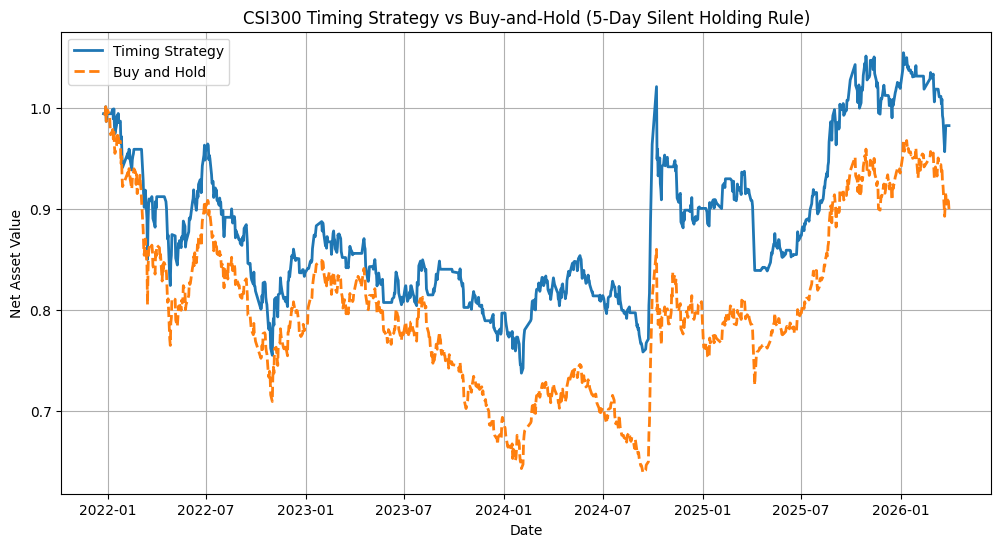

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df["date"], result_df["strategy_nav"], label="Timing Strategy", linewidth=2)
plt.plot(result_df["date"], result_df["buy_hold_nav"], label="Buy and Hold", linewidth=2, linestyle="--")
plt.legend()
plt.title("CSI300 Timing Strategy vs Buy-and-Hold (5-Day Silent Holding Rule)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.grid(True)
plt.show()

#### Step 8: Compute basic performance metrics

In [11]:
import numpy as np

def annualized_return(ret_series, periods_per_year=244):
    nav = (1 + ret_series).prod()
    n = len(ret_series)
    return nav ** (periods_per_year / n) - 1

def annualized_volatility(ret_series, periods_per_year=244):
    return ret_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret_series, periods_per_year=244, rf=0):
    ann_ret = annualized_return(ret_series, periods_per_year)
    ann_vol = annualized_volatility(ret_series, periods_per_year)
    return (ann_ret - rf) / ann_vol if ann_vol != 0 else np.nan

def max_drawdown(nav_series):
    rolling_max = nav_series.cummax()
    drawdown = nav_series / rolling_max - 1
    return drawdown.min()

print("Strategy Annual Return:", annualized_return(result_df["strategy_ret"]))
print("Strategy Annual Vol   :", annualized_volatility(result_df["strategy_ret"]))
print("Strategy Sharpe       :", sharpe_ratio(result_df["strategy_ret"]))
print("Strategy Max Drawdown :", max_drawdown(result_df["strategy_nav"]))

print("BuyHold Annual Return:", annualized_return(result_df["buy_hold_ret"]))
print("BuyHold Annual Vol   :", annualized_volatility(result_df["buy_hold_ret"]))
print("BuyHold Sharpe       :", sharpe_ratio(result_df["buy_hold_ret"]))
print("BuyHold Max Drawdown :", max_drawdown(result_df["buy_hold_nav"]))

print("Average daily exposure:", result_df["signal"].mean())

Strategy Annual Return: -0.004123842937946098
Strategy Annual Vol   : 0.16327563177987492
Strategy Sharpe       : -0.02525694062850594
Strategy Max Drawdown : -0.2639208008713336
BuyHold Annual Return: -0.024824518403377405
BuyHold Annual Vol   : 0.17510666525267465
BuyHold Sharpe       : -0.1417679810620357
BuyHold Max Drawdown : -0.3625363299652715
Average daily exposure: 0.8098933074684772


## Step 9: Wrap the evaluation and backtest functions into reusable helpers
All models below reuse the same classification evaluation logic and the same 5-day silent-holding backtest.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np

def annualized_return(ret_series, periods_per_year=244):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return np.nan
    nav = (1 + ret_series).prod()
    return nav ** (periods_per_year / len(ret_series)) - 1

def annualized_volatility(ret_series, periods_per_year=244):
    ret_series = pd.Series(ret_series).dropna()
    if len(ret_series) == 0:
        return np.nan
    return ret_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(ret_series, periods_per_year=244, rf=0):
    ann_ret = annualized_return(ret_series, periods_per_year)
    ann_vol = annualized_volatility(ret_series, periods_per_year)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return (ann_ret - rf) / ann_vol

def max_drawdown(nav_series):
    nav_series = pd.Series(nav_series).dropna()
    if len(nav_series) == 0:
        return np.nan
    rolling_max = nav_series.cummax()
    drawdown = nav_series / rolling_max - 1
    return drawdown.min()

def backtest_from_prob(dates_test, y_prob, threshold=0.5,
                       price_path="CSI300_merged_2005_2026.csv",
                       horizon=5):
    """
    Scheme A backtest:
    - A signal is generated on the sample date t using the past 20-day window.
    - If the model enters, the strategy holds the CSI300 for the next `horizon`
      trading days (t+1 to t+horizon).
    - During those holding days, all new signals are ignored.
    - If the raw signal is 0, the strategy stays in cash and can evaluate the
      next available signal on the following day.
    """
    signal_df = pd.DataFrame({
        "date": pd.to_datetime(dates_test),
        "y_prob": y_prob
    }).sort_values("date").reset_index(drop=True)
    signal_df["raw_signal"] = (signal_df["y_prob"] > threshold).astype(int)

    px = pd.read_csv(price_path)
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").reset_index(drop=True)
    px["ret_1d"] = px["close"].pct_change()

    date_to_idx = {pd.Timestamp(d): i for i, d in enumerate(px["date"])}
    positions = np.zeros(len(px), dtype=int)

    used_signals = []
    ignored_signals = []
    active_until_idx = -1

    for _, row in signal_df.iterrows():
        signal_date = pd.Timestamp(row["date"])
        raw_signal = int(row["raw_signal"])
        idx = date_to_idx.get(signal_date)

        if idx is None or idx + horizon >= len(px):
            used_signals.append(0)
            ignored_signals.append(0)
            continue

        # Allow a new decision on the day the previous holding window ends.
        if idx < active_until_idx:
            used_signals.append(0)
            ignored_signals.append(1)
            continue

        if raw_signal == 1:
            positions[idx + 1: idx + horizon + 1] = 1
            active_until_idx = idx + horizon
            used_signals.append(1)
            ignored_signals.append(0)
        else:
            used_signals.append(0)
            ignored_signals.append(0)

    signal_df["used_signal"] = used_signals
    signal_df["ignored_signal"] = ignored_signals

    valid_signal_dates = signal_df["date"].map(date_to_idx).dropna().astype(int)
    if len(valid_signal_dates) == 0:
        raise ValueError("No test dates were matched to the price file.")

    start_idx = int(valid_signal_dates.iloc[0]) + 1
    end_idx = min(int(valid_signal_dates.iloc[-1]) + horizon, len(px) - 1)

    result_df = px.loc[start_idx:end_idx, ["date", "ret_1d"]].copy().reset_index(drop=True)
    result_df["signal"] = positions[start_idx:end_idx + 1]
    result_df["strategy_ret"] = result_df["signal"] * result_df["ret_1d"]
    result_df["buy_hold_ret"] = result_df["ret_1d"]

    result_df["strategy_nav"] = (1 + result_df["strategy_ret"]).cumprod()
    result_df["buy_hold_nav"] = (1 + result_df["buy_hold_ret"]).cumprod()

    summary = {
        "Annual Return": annualized_return(result_df["strategy_ret"]),
        "Annual Vol": annualized_volatility(result_df["strategy_ret"]),
        "Sharpe": sharpe_ratio(result_df["strategy_ret"]),
        "Max Drawdown": max_drawdown(result_df["strategy_nav"]),
        "BuyHold Annual Return": annualized_return(result_df["buy_hold_ret"]),
        "BuyHold Annual Vol": annualized_volatility(result_df["buy_hold_ret"]),
        "BuyHold Sharpe": sharpe_ratio(result_df["buy_hold_ret"]),
        "BuyHold Max Drawdown": max_drawdown(result_df["buy_hold_nav"]),
        "Average Exposure": result_df["signal"].mean(),
        "Used Signal Ratio": signal_df["used_signal"].mean(),
        "Ignored Signal Ratio": signal_df["ignored_signal"].mean()
    }

    return result_df, summary, signal_df

model_summaries = []
model_curves = {}

import matplotlib.pyplot as plt

def plot_model_vs_hs300(bt_df, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(bt_df["date"], bt_df["strategy_nav"], label=f"{model_name} Timing Strategy", linewidth=2)
    plt.plot(bt_df["date"], bt_df["buy_hold_nav"], label="HS300 Buy-and-Hold", linewidth=2, linestyle="--")
    plt.title(f"{model_name} vs HS300 Buy-and-Hold (5-Day Silent Holding Rule)")
    plt.xlabel("Date")
    plt.ylabel("Net Asset Value")
    plt.legend()
    plt.grid(True)
    plt.show()

def summarize_result(model_name, y_true, y_pred, bt_df):
    summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Annual Return": annualized_return(bt_df["strategy_ret"]),
        "Annual Vol": annualized_volatility(bt_df["strategy_ret"]),
        "Sharpe": sharpe_ratio(bt_df["strategy_ret"]),
        "Max Drawdown": max_drawdown(bt_df["strategy_nav"]),
        "BuyHold Annual Return": annualized_return(bt_df["buy_hold_ret"]),
        "BuyHold Annual Vol": annualized_volatility(bt_df["buy_hold_ret"]),
        "BuyHold Sharpe": sharpe_ratio(bt_df["buy_hold_ret"]),
        "BuyHold Max Drawdown": max_drawdown(bt_df["buy_hold_nav"]),
    }
    return summary

## Step 10: Prepare the shared model inputs
Traditional machine learning models use flattened 2D inputs. SVM, KNN, and MLP also use the standardized version.

In [13]:
from sklearn.preprocessing import StandardScaler

# Flattened input for traditional machine learning models.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_valid_flat = X_valid.reshape(X_valid.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Standardized input, commonly used by SVM, KNN, and MLP.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_valid_scaled = scaler.transform(X_valid_flat)
X_test_scaled  = scaler.transform(X_test_flat)

print("X_train_flat shape:", X_train_flat.shape)
print("X_valid_flat shape:", X_valid_flat.shape)
print("X_test_flat shape :", X_test_flat.shape)

X_train_flat shape: (3079, 80)
X_valid_flat shape: (1027, 80)
X_test_flat shape : (1027, 80)


## Step 11: Add the Logistic Regression result to the unified summary

In [14]:
# If the earlier logistic model has already been trained, reuse `clf` and `y_test_prob` directly.
# If you restart execution from this cell, uncomment the next three lines and refit the logistic model.
# clf = LogisticRegression(max_iter=2000)
# clf.fit(X_train_flat, y_train)
# y_test_prob = clf.predict_proba(X_test_flat)[:, 1]

y_test_pred_logit = (y_test_prob > 0.5).astype(int)
bt_logit, bt_logit_summary, signal_logit = backtest_from_prob(dates_test, y_test_prob)
model_summaries.append(summarize_result("Logistic Regression", y_test, y_test_pred_logit, bt_logit))
model_curves["Logistic Regression"] = bt_logit[["date", "strategy_nav"]].copy()

print(classification_report(y_test, y_test_pred_logit))
print(model_summaries[-1])

              precision    recall  f1-score   support

           0       0.53      0.34      0.42       538
           1       0.48      0.67      0.56       489

    accuracy                           0.50      1027
   macro avg       0.50      0.50      0.49      1027
weighted avg       0.51      0.50      0.48      1027

{'Model': 'Logistic Regression', 'Accuracy': 0.49659201557935734, 'Precision': 0.47941176470588237, 'Recall': 0.6666666666666666, 'F1': 0.5577416595380668, 'Annual Return': np.float64(-0.004123842937946098), 'Annual Vol': np.float64(0.16327563177987492), 'Sharpe': np.float64(-0.02525694062850594), 'Max Drawdown': np.float64(-0.2639208008713336), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


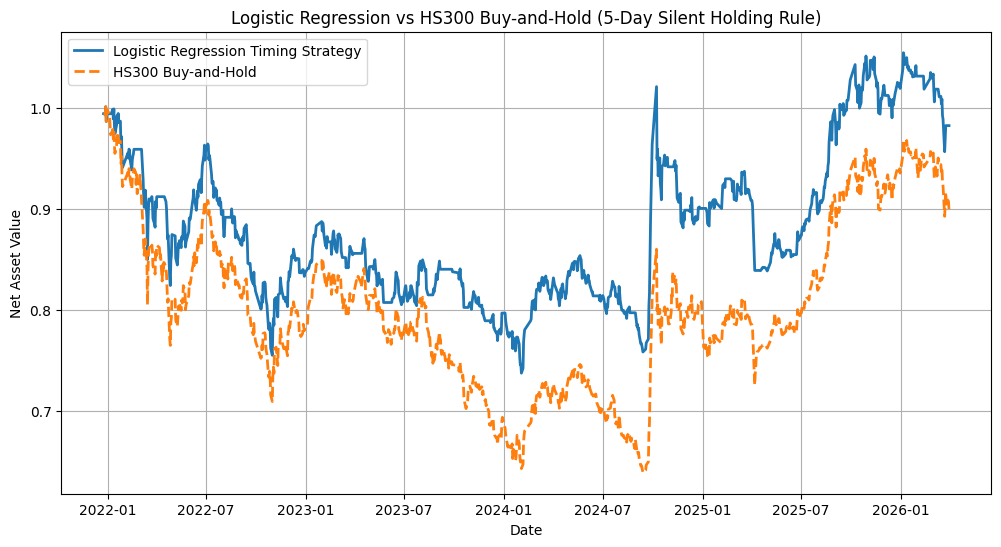

In [15]:

plot_model_vs_hs300(bt_logit, "Logistic Regression")


## Step 12: Random Forest

In [16]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)

rf_prob = rf.predict_proba(X_test_flat)[:, 1]
rf_pred = (rf_prob > 0.5).astype(int)

bt_rf, bt_rf_summary, signal_rf = backtest_from_prob(dates_test, rf_prob)
model_summaries.append(summarize_result("Random Forest", y_test, rf_pred, bt_rf))
model_curves["Random Forest"] = bt_rf[["date", "strategy_nav"]].copy()

print(classification_report(y_test, rf_pred))
print(model_summaries[-1])


              precision    recall  f1-score   support

           0       0.62      0.09      0.16       538
           1       0.48      0.94      0.64       489

    accuracy                           0.49      1027
   macro avg       0.55      0.51      0.40      1027
weighted avg       0.56      0.49      0.39      1027

{'Model': 'Random Forest', 'Accuracy': 0.4946445959104187, 'Precision': 0.4842105263157895, 'Recall': 0.9406952965235174, 'F1': 0.6393328700486449, 'Annual Return': np.float64(-0.017706201977701563), 'Annual Vol': np.float64(0.17266351722136114), 'Sharpe': np.float64(-0.10254744176791872), 'Max Drawdown': np.float64(-0.3426420208322536), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


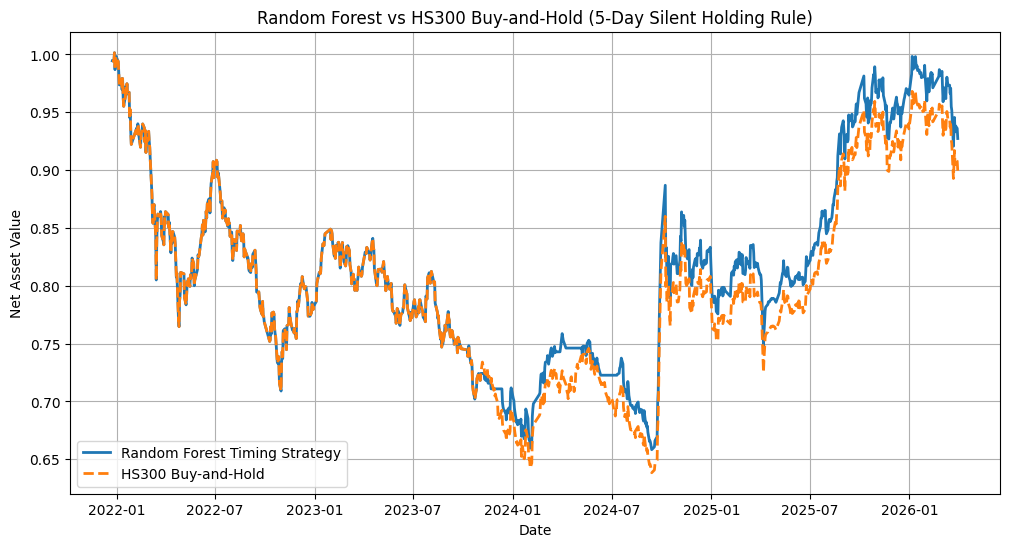

In [17]:

plot_model_vs_hs300(bt_rf, "Random Forest")


## Step 13: Gradient Boosting

In [18]:

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_flat, y_train)

gb_prob = gb.predict_proba(X_test_flat)[:, 1]
gb_pred = (gb_prob > 0.5).astype(int)

bt_gb, bt_gb_summary, signal_gb = backtest_from_prob(dates_test, gb_prob)
model_summaries.append(summarize_result("Gradient Boosting", y_test, gb_pred, bt_gb))
model_curves["Gradient Boosting"] = bt_gb[["date", "strategy_nav"]].copy()

print(classification_report(y_test, gb_pred))
print(model_summaries[-1])


              precision    recall  f1-score   support

           0       0.50      0.38      0.43       538
           1       0.46      0.59      0.52       489

    accuracy                           0.48      1027
   macro avg       0.48      0.48      0.48      1027
weighted avg       0.48      0.48      0.47      1027

{'Model': 'Gradient Boosting', 'Accuracy': 0.4790652385589094, 'Precision': 0.46325878594249204, 'Recall': 0.5930470347648262, 'F1': 0.5201793721973094, 'Annual Return': np.float64(0.0015771638808133037), 'Annual Vol': np.float64(0.15511572564641016), 'Sharpe': np.float64(0.010167659495778558), 'Max Drawdown': np.float64(-0.2969914069998918), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


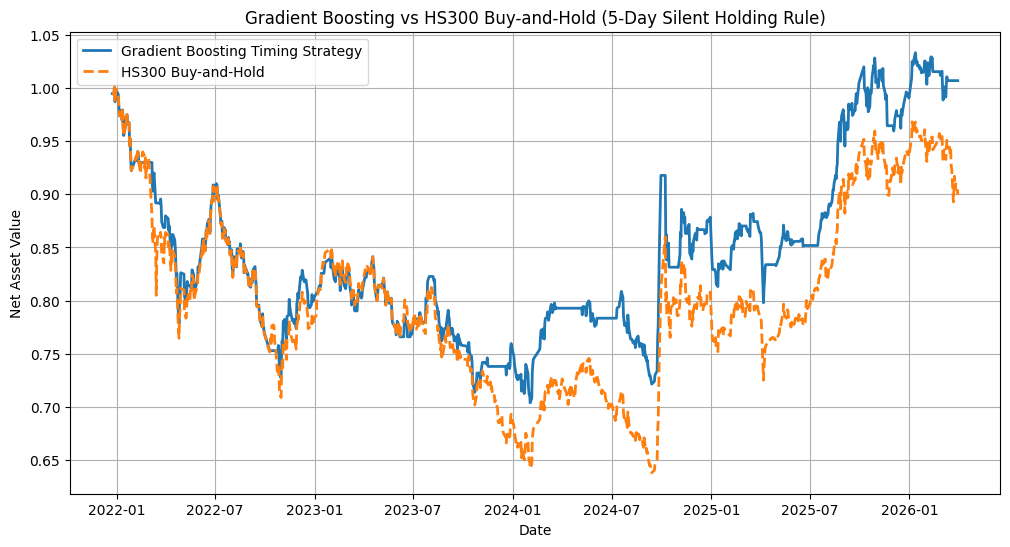

In [19]:

plot_model_vs_hs300(bt_gb, "Gradient Boosting")


## Step 14: XGBoost

In [20]:

try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
    xgb_model.fit(X_train_flat, y_train)

    xgb_prob = xgb_model.predict_proba(X_test_flat)[:, 1]
    xgb_pred = (xgb_prob > 0.5).astype(int)

    bt_xgb, bt_xgb_summary, signal_xgb = backtest_from_prob(dates_test, xgb_prob)
    model_summaries.append(summarize_result("XGBoost", y_test, xgb_pred, bt_xgb))
    model_curves["XGBoost"] = bt_xgb[["date", "strategy_nav"]].copy()

    print(classification_report(y_test, xgb_pred))
    print(model_summaries[-1])

except Exception as e:
    print("XGBoost was skipped:", e)


              precision    recall  f1-score   support

           0       0.51      0.41      0.46       538
           1       0.46      0.56      0.51       489

    accuracy                           0.48      1027
   macro avg       0.49      0.49      0.48      1027
weighted avg       0.49      0.48      0.48      1027

{'Model': 'XGBoost', 'Accuracy': 0.48296007789678674, 'Precision': 0.4642857142857143, 'Recall': 0.558282208588957, 'F1': 0.5069637883008357, 'Annual Return': np.float64(0.029150799595649923), 'Annual Vol': np.float64(0.15705954595908822), 'Sharpe': np.float64(0.18560348826707607), 'Max Drawdown': np.float64(-0.2434665924366305), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


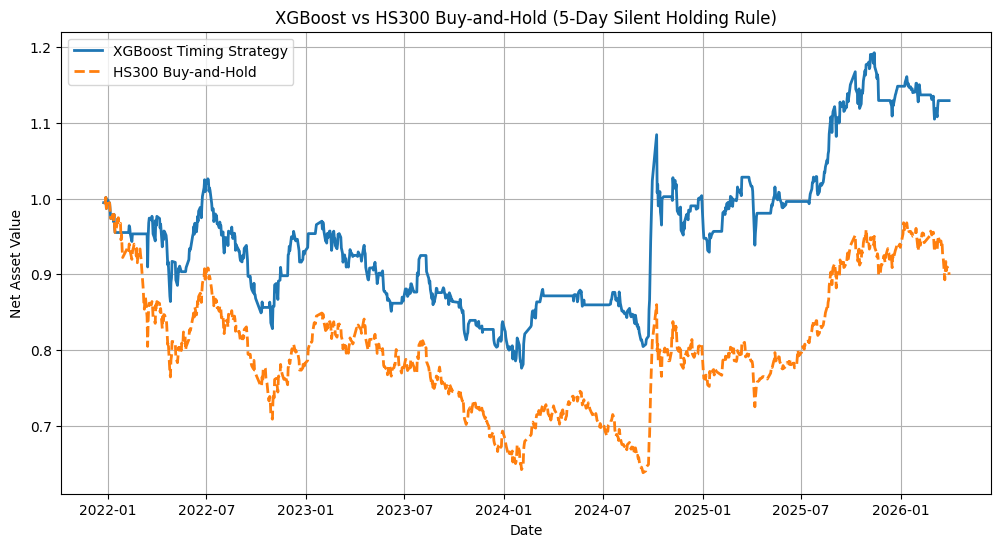

In [21]:

if "bt_xgb" in globals():
    plot_model_vs_hs300(bt_xgb, "XGBoost")
else:
    print("The XGBoost plot was skipped because the model was not trained.")


## Step 15: SVM

In [22]:

from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

svm_prob = svm.predict_proba(X_test_scaled)[:, 1]
svm_pred = (svm_prob > 0.5).astype(int)

bt_svm, bt_svm_summary, signal_svm = backtest_from_prob(dates_test, svm_prob)
model_summaries.append(summarize_result("SVM", y_test, svm_pred, bt_svm))
model_curves["SVM"] = bt_svm[["date", "strategy_nav"]].copy()

print(classification_report(y_test, svm_pred))
print(model_summaries[-1])


              precision    recall  f1-score   support

           0       1.00      0.00      0.00       538
           1       0.48      1.00      0.65       489

    accuracy                           0.48      1027
   macro avg       0.74      0.50      0.32      1027
weighted avg       0.75      0.48      0.31      1027

{'Model': 'SVM', 'Accuracy': 0.4771178188899708, 'Precision': 0.4766081871345029, 'Recall': 1.0, 'F1': 0.6455445544554456, 'Annual Return': np.float64(-0.0226592158245561), 'Annual Vol': np.float64(0.17504825007263866), 'Sharpe': np.float64(-0.1294455432439533), 'Max Drawdown': np.float64(-0.3625363299652715), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


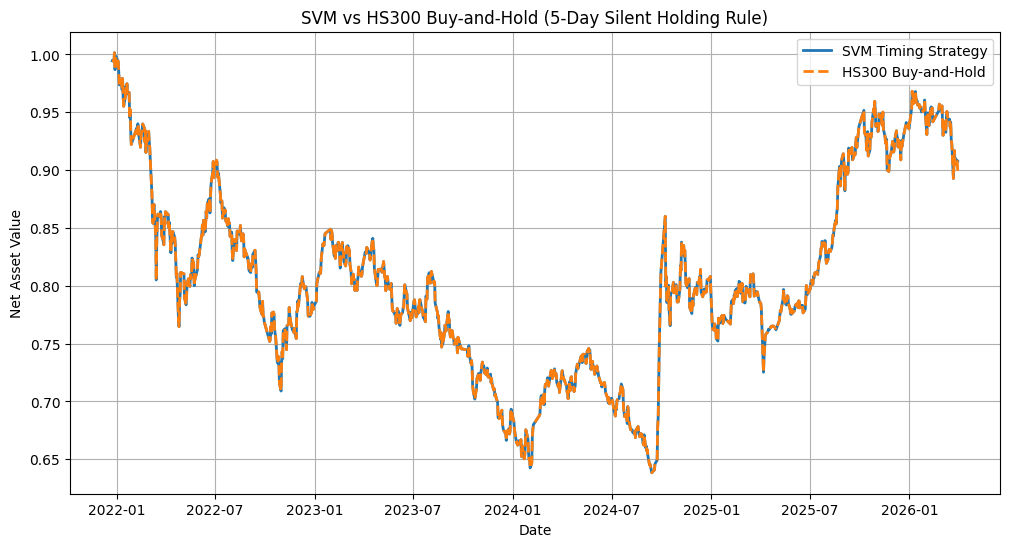

In [23]:

plot_model_vs_hs300(bt_svm, "SVM")


## Step 16: KNN

In [24]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

knn_prob = knn.predict_proba(X_test_scaled)[:, 1]
knn_pred = (knn_prob > 0.5).astype(int)

bt_knn, bt_knn_summary, signal_knn = backtest_from_prob(dates_test, knn_prob)
model_summaries.append(summarize_result("KNN", y_test, knn_pred, bt_knn))
model_curves["KNN"] = bt_knn[["date", "strategy_nav"]].copy()

print(classification_report(y_test, knn_pred))
print(model_summaries[-1])


              precision    recall  f1-score   support

           0       0.52      0.44      0.48       538
           1       0.47      0.55      0.51       489

    accuracy                           0.49      1027
   macro avg       0.50      0.50      0.49      1027
weighted avg       0.50      0.49      0.49      1027

{'Model': 'KNN', 'Accuracy': 0.4936708860759494, 'Precision': 0.47294938917975565, 'Recall': 0.5541922290388548, 'F1': 0.5103578154425612, 'Annual Return': np.float64(0.038528480807843435), 'Annual Vol': np.float64(0.14718672462298268), 'Sharpe': np.float64(0.26176600441740755), 'Max Drawdown': np.float64(-0.3187489350794046), 'BuyHold Annual Return': np.float64(-0.024824518403377405), 'BuyHold Annual Vol': np.float64(0.17510666525267465), 'BuyHold Sharpe': np.float64(-0.1417679810620357), 'BuyHold Max Drawdown': np.float64(-0.3625363299652715)}


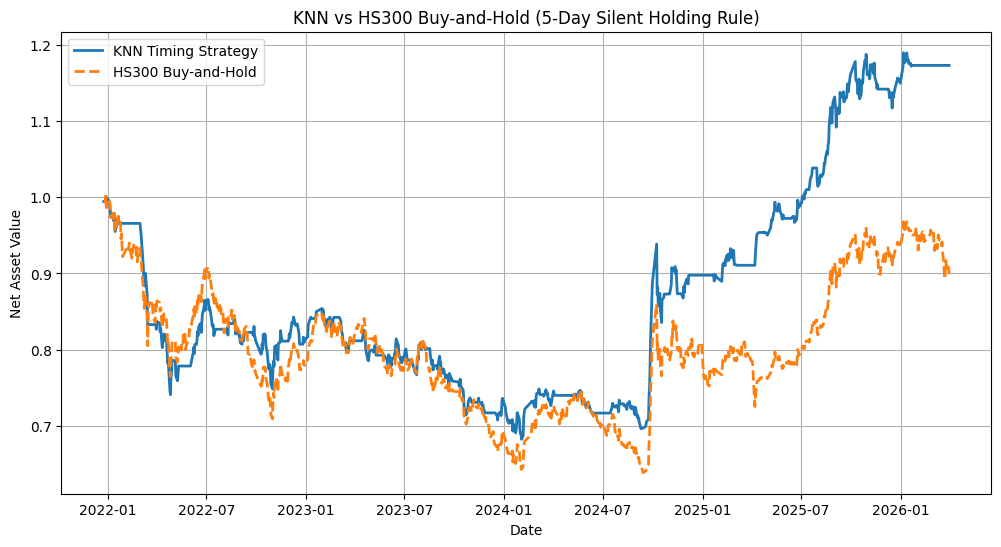

In [25]:

plot_model_vs_hs300(bt_knn, "KNN")


## Step 17: MLP

In [26]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_mlp = mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

mlp_prob = mlp.predict(X_test_scaled).ravel()
mlp_pred = (mlp_prob > 0.5).astype(int)

bt_mlp, bt_mlp_summary, signal_mlp = backtest_from_prob(dates_test, mlp_prob)
model_summaries.append(summarize_result("MLP", y_test, mlp_pred, bt_mlp))
model_curves["MLP"] = bt_mlp[["date", "strategy_nav"]].copy()

print(classification_report(y_test, mlp_pred))
print(model_summaries[-1])


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5401 - loss: 0.7076 - val_accuracy: 0.4596 - val_loss: 0.7101
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - accuracy: 0.5359 - loss: 0.6916 - val_accuracy: 0.4479 - val_loss: 0.7006
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.5492 - loss: 0.6868 - val_accuracy: 0.4645 - val_loss: 0.7094
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.5443 - loss: 0.6866 - val_accuracy: 0.4567 - val_loss: 0.6995
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - accuracy: 0.5476 - loss: 0.6843 - val_accuracy: 0.4606 - val_loss: 0.6964
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - accuracy: 0.5573 - loss: 0.6845 - val_accuracy: 0.4869 - val_loss: 0.6955
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.5401 - loss: 0.6824 - val_accuracy: 0.4791 - val_loss: 0.6985
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - accuracy: 0.5567 - loss: 0.6837 - val_accura

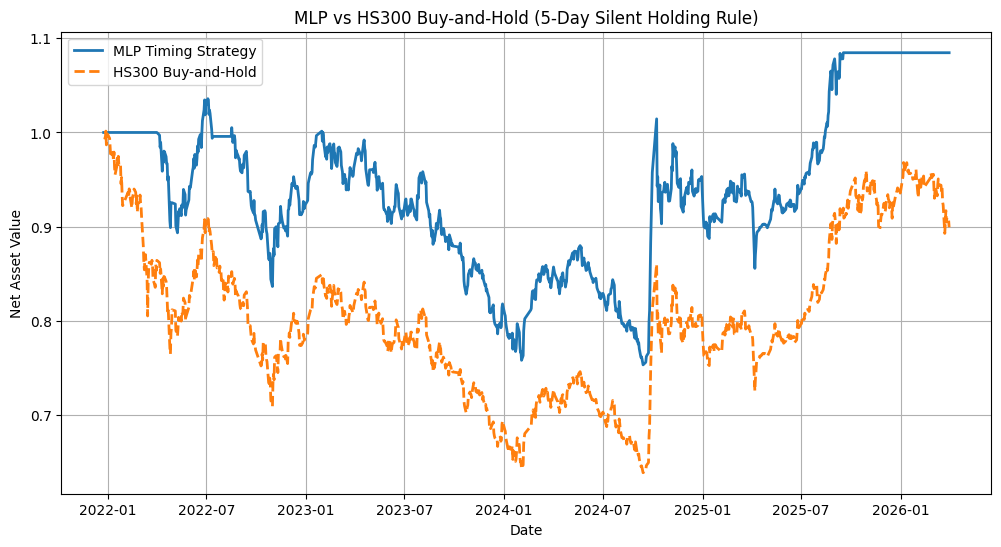

In [27]:

plot_model_vs_hs300(bt_mlp, "MLP")


## Step 18: 1D CNN

In [28]:

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

tf.random.set_seed(42)

cnn1d = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(32, kernel_size=3, activation="relu"),
    Conv1D(32, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

cnn1d.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_cnn1d = cnn1d.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

cnn1d_prob = cnn1d.predict(X_test).ravel()
cnn1d_pred = (cnn1d_prob > 0.5).astype(int)

bt_cnn1d, bt_cnn1d_summary, signal_cnn1d = backtest_from_prob(dates_test, cnn1d_prob)
model_summaries.append(summarize_result("1D CNN", y_test, cnn1d_pred, bt_cnn1d))
model_curves["1D CNN"] = bt_cnn1d[["date", "strategy_nav"]].copy()

print(classification_report(y_test, cnn1d_pred))
print(model_summaries[-1])


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5076 - loss: 16.4911 - val_accuracy: 0.5521 - val_loss: 1.2638
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.5161 - loss: 2.2996 - val_accuracy: 0.5550 - val_loss: 0.7397
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.5024 - loss: 0.7457 - val_accuracy: 0.5521 - val_loss: 0.6920
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.5184 - loss: 0.7059 - val_accuracy: 0.5521 - val_loss: 0.7202
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.5171 - loss: 0.7084 - val_accuracy: 0.5521 - val_loss: 0.7305
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.5145 - loss: 0.7148 - val_accuracy: 0.5521 - val_loss: 0.7206
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.5132 - loss: 0.7161 - val_accuracy: 0.5531 - val_loss: 0.7020
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.5274 - loss: 0.7095 - val_accur

/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

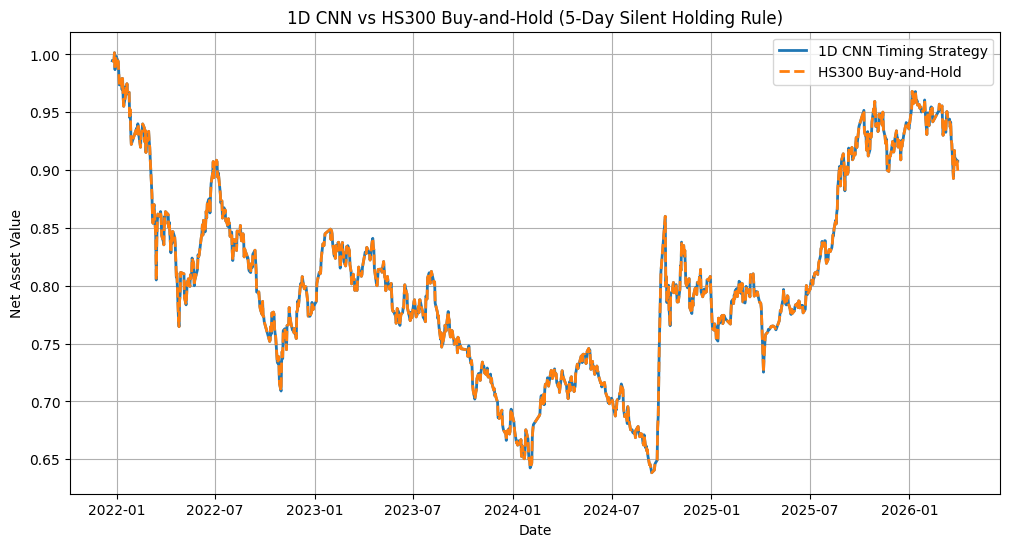

In [29]:

plot_model_vs_hs300(bt_cnn1d, "1D CNN")


## Step 19: Rebuild image inputs that keep only OHLC while matching the stronger plotting style

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "."
price_path = os.path.join(folder_path, "CSI300_merged_2005_2026.csv")

img_df = pd.read_csv(price_path)
img_df["date"] = pd.to_datetime(img_df["date"])
img_df = img_df.sort_values("date").reset_index(drop=True)

date_to_idx = {pd.Timestamp(d): i for i, d in enumerate(img_df["date"])}
feature_cols_img = ["open", "high", "low", "close"]
WINDOW = 20

def build_raw_windows_from_dates(sample_dates, df, date_to_idx, feature_cols, window=20):
    raw_windows = []
    for d in pd.to_datetime(sample_dates):
        idx = date_to_idx.get(pd.Timestamp(d))
        if idx is None:
            raise ValueError(f"Date {d} was not found in the source dataframe.")
        if idx < window - 1:
            raise ValueError(f"Date {d} does not have enough history for a {window}-day window.")

        window_df = df.loc[idx - window + 1: idx, feature_cols].copy()
        if len(window_df) != window:
            raise ValueError(f"Window length mismatch for date {d}.")
        if window_df.isnull().any().any():
            raise ValueError(f"Window for date {d} contains NaN values.")

        raw_windows.append(window_df.values.astype(np.float32))

    return np.array(raw_windows, dtype=np.float32)

X_train_img_raw = build_raw_windows_from_dates(dates_train, img_df, date_to_idx, feature_cols_img, window=WINDOW)
X_valid_img_raw = build_raw_windows_from_dates(dates_valid, img_df, date_to_idx, feature_cols_img, window=WINDOW)
X_test_img_raw = build_raw_windows_from_dates(dates_test, img_df, date_to_idx, feature_cols_img, window=WINDOW)

print("X_train_img_raw shape:", X_train_img_raw.shape)
print("X_valid_img_raw shape:", X_valid_img_raw.shape)
print("X_test_img_raw shape :", X_test_img_raw.shape)

X_train_img_raw shape: (3079, 20, 4)
X_valid_img_raw shape: (1027, 20, 4)
X_test_img_raw shape : (1027, 20, 4)


## Step 19 (supplement): Use the same rendering style as the stronger notebook, but keep only OHLC

In [31]:
def ohlc_only_stronger_style_image(window, height=64):
    """
    window: shape (20, 4)
            columns = [open, high, low, close]
    return: grayscale image, shape (height, width)

    To keep the setup as comparable as possible to the stronger version:
    - use the same image height,
    - use 3 pixels per trading day,
    - keep the top 80% as the price area,
    - leave the bottom 20% blank because volume is not included here,
    - do not draw the moving average line.
    """
    n_days = window.shape[0]
    width = n_days * 3
    img = np.zeros((height, width), dtype=np.uint8)

    # Keep the same layout as the stronger notebook: the top 80% is the price area and the bottom 20% is blank.
    price_h = int(height * 0.8)

    opens = window[:, 0]
    highs = window[:, 1]
    lows = window[:, 2]
    closes = window[:, 3]

    max_price = highs.max()
    min_price = lows.min()
    if max_price == min_price:
        max_price += 1e-6

    def price_to_y(price):
        y = int(round((max_price - price) / (max_price - min_price) * (price_h - 1)))
        return np.clip(y, 0, price_h - 1)

    for i in range(n_days):
        o, h, l, c = window[i]
        x0 = i * 3

        y_open = price_to_y(o)
        y_high = price_to_y(h)
        y_low = price_to_y(l)
        y_close = price_to_y(c)

        # OHLC rendering in the stronger notebook style.
        img[min(y_high, y_low):max(y_high, y_low)+1, x0+1] = 255
        img[y_open, x0] = 255
        img[y_close, x0+2] = 255

    return img

def build_image_dataset(X_raw, height=64):
    imgs = [ohlc_only_stronger_style_image(x, height=height) for x in X_raw]
    imgs = np.array(imgs, dtype=np.float32) / 255.0
    imgs = imgs[..., np.newaxis]
    return imgs

X_train_img = build_image_dataset(X_train_img_raw, height=64)
X_valid_img = build_image_dataset(X_valid_img_raw, height=64)
X_test_img = build_image_dataset(X_test_img_raw, height=64)

print("X_train_img shape:", X_train_img.shape)
print("X_valid_img shape:", X_valid_img.shape)
print("X_test_img shape :", X_test_img.shape)

X_train_img shape: (3079, 64, 60, 1)
X_valid_img shape: (1027, 64, 60, 1)
X_test_img shape : (1027, 64, 60, 1)


## Step 19 (supplement): Display a few OHLC-only sample images

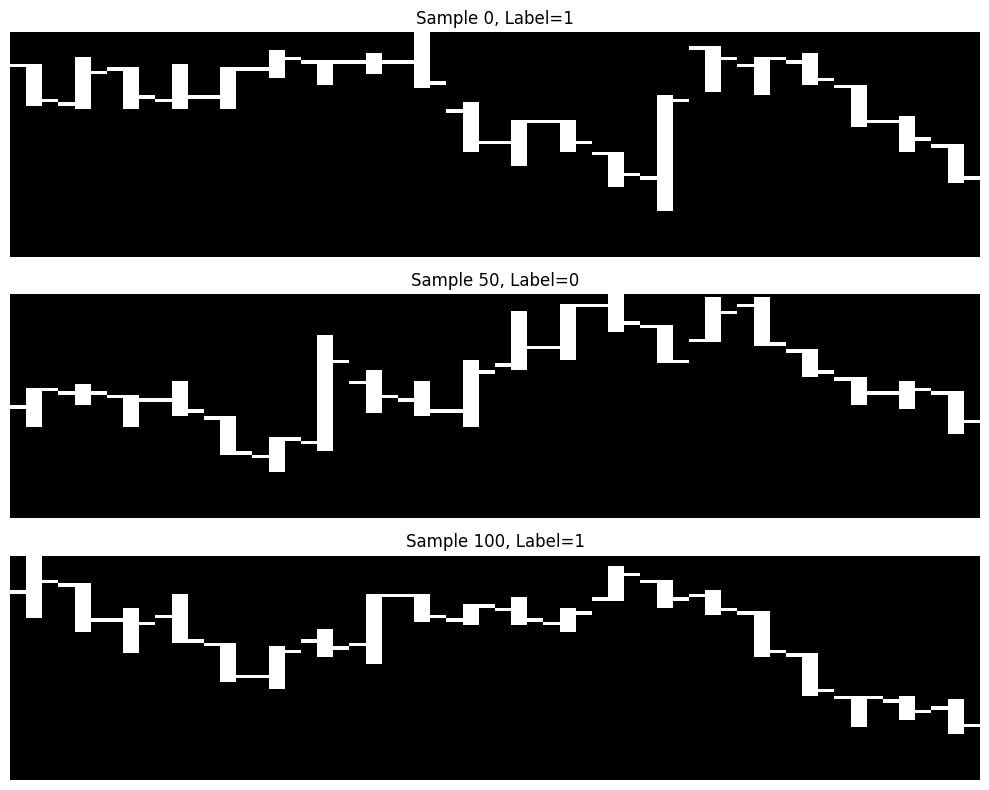

In [32]:

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for j, idx in enumerate([0, 50, 100]):
    axes[j].imshow(X_train_img[idx].squeeze(), cmap='gray', aspect='auto')
    axes[j].set_title(f'Sample {idx}, Label={y_train[idx]}')
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Step 20: Train a 2D CNN with the stronger architecture on pure OHLC images

Epoch 1/100
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5263 - loss: 0.6914
Epoch 1: val_loss improved from None to 0.83653, saving model to /Users/daijinyang/Desktop/HS300/best_cnn2d_model_stronger_ohlc_only_from_baseline.keras

Epoch 1: finished saving model to /Users/daijinyang/Desktop/HS300/best_cnn2d_model_stronger_ohlc_only_from_baseline.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.5469 - loss: 0.6858 - val_accuracy: 0.5521 - val_loss: 0.8365 - learning_rate: 5.0000e-04
Epoch 2/100
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5610 - loss: 0.6879
Epoch 2: val_loss improved from 0.83653 to 0.74517, saving model to /Users/daijinyang/Desktop/HS300/best_cnn2d_model_stronger_ohlc_only_from_baseline.keras

Epoch 2: finished saving model to /Users/daijinyang/Desktop/HS300/best_cnn2d_model_stronger_ohlc_only_from_baseline.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.5632 - loss: 0.6821 - val_accuracy: 0.5521 - val_loss: 0.7452 - learn

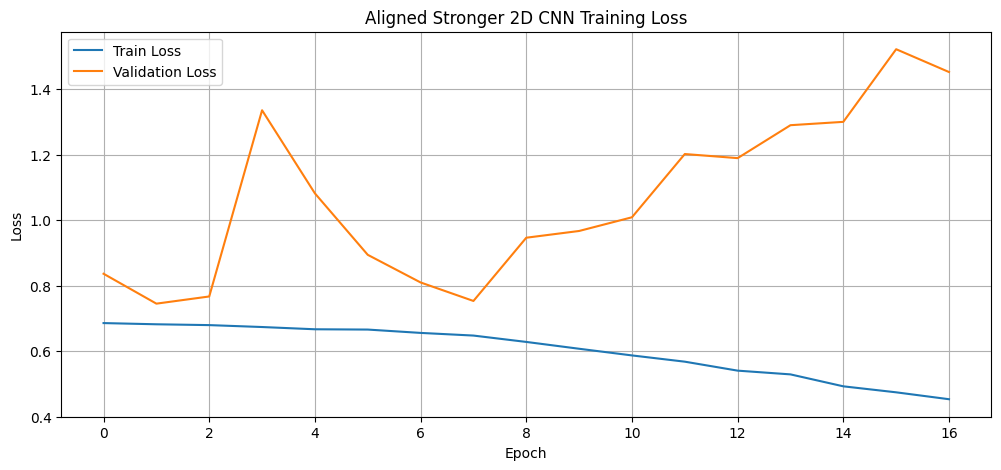

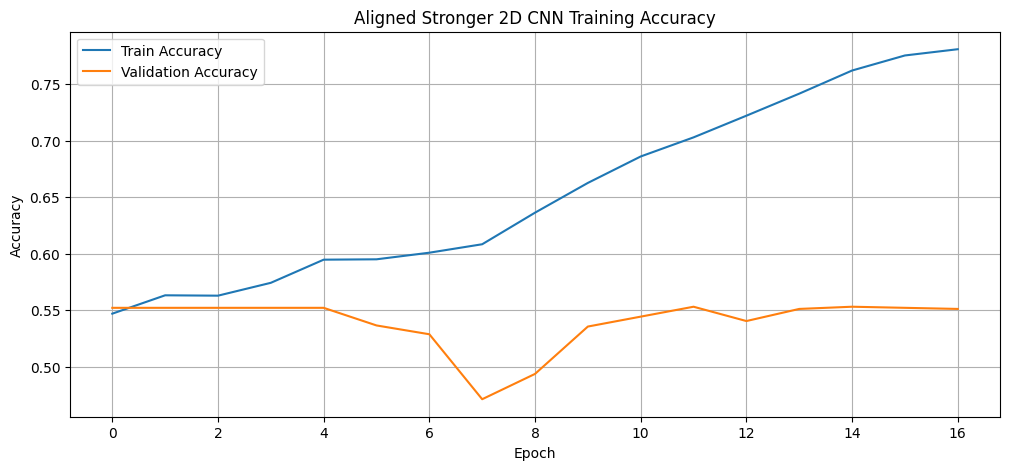

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Classification report for Stronger 2D CNN:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       538
           1       0.48      1.00      0.65       489

    accuracy                           0.48      1027
   macro avg       0.24      0.50      0.32      1027
weighted avg       0.23      0.48      0.31      1027

Backtest summary for Stronger 2D CNN:
Annual Return           -0.022659
Annual Vol               0.175048
Sharpe                  -0.129446
Max Drawdown            -0.362536
BuyHold Annual Return   -0.024825
BuyHold Annual Vol       0.175107
BuyHold Sharpe          -0.141768
BuyHold Max Drawdown    -0.362536
Average Exposure         0.999030
Used Signal Ratio        0.200584
Ignored Signal Ratio     0.799416
dtype: float64
Stored model summary row:
{'Model': 'Stronger 2D CNN (OHLC-only Image-based)', 'Accuracy': 0.4761441090555015, 'Precision': 0.4761441090555015, 'Recall': 1.0, 'F1'

/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [33]:
import random
import os
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Build a stronger 2D CNN using OHLC-only image inputs
cnn2d = Sequential([
    Input(shape=X_train_img.shape[1:]),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.15),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

# Compile the model
cnn2d.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Define callbacks
checkpoint_path = os.path.join(folder_path, "best_cnn2d_model_stronger_ohlc_only_from_baseline.keras")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Train the model
history_cnn2d = cnn2d.fit(
    X_train_img,
    y_train,
    validation_data=(X_valid_img, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(12, 5))
plt.plot(history_cnn2d.history["loss"], label="Train Loss")
plt.plot(history_cnn2d.history["val_loss"], label="Validation Loss")
plt.title("Aligned Stronger 2D CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot training accuracy
plt.figure(figsize=(12, 5))
plt.plot(history_cnn2d.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn2d.history["val_accuracy"], label="Validation Accuracy")
plt.title("Aligned Stronger 2D CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Generate predicted probabilities and class labels
cnn2d_prob = cnn2d.predict(X_test_img).ravel()
cnn2d_pred = (cnn2d_prob > 0.5).astype(int)

# Run Scheme A backtest:
# 5-day holding period with a 5-day silent period
bt_cnn2d, bt_cnn2d_summary, signal_cnn2d = backtest_from_prob(dates_test, cnn2d_prob)

# Store model summary
model_summaries.append(
    summarize_result(
        "Stronger 2D CNN (OHLC-only Image-based)",
        y_test,
        cnn2d_pred,
        bt_cnn2d
    )
)

# Store the NAV curve for later comparison plots
model_curves["Stronger 2D CNN (OHLC-only Image-based)"] = bt_cnn2d[["date", "strategy_nav"]].copy()

# Print classification metrics
print("Classification report for Stronger 2D CNN:")
print(classification_report(y_test, cnn2d_pred))

# Print backtest summary
print("Backtest summary for Stronger 2D CNN:")
print(pd.Series(bt_cnn2d_summary))

# Print combined model summary row
print("Stored model summary row:")
print(model_summaries[-1])

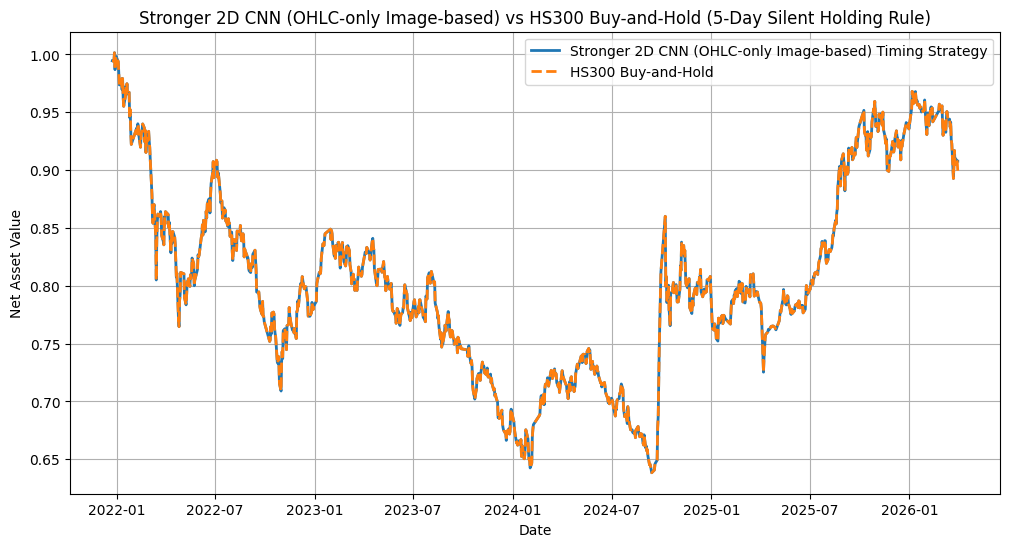

In [34]:
plot_model_vs_hs300(bt_cnn2d, 'Stronger 2D CNN (OHLC-only Image-based)')

## Step 21: Summarize all model results

In [35]:

summary_df = pd.DataFrame(model_summaries)
summary_df = summary_df.sort_values(by="Sharpe", ascending=False).reset_index(drop=True)
summary_df


,Model,Accuracy,Precision,Recall,F1,Annual Return,Annual Vol,Sharpe,Max Drawdown,BuyHold Annual Return,BuyHold Annual Vol,BuyHold Sharpe,BuyHold Max Drawdown
0,KNN,0.493671,0.472949,0.554192,0.510358,0.038528,0.147187,0.261766,-0.318749,-0.024825,0.175107,-0.141768,-0.362536
1,XGBoost,0.482960,0.464286,0.558282,0.506964,0.029151,0.157060,0.185603,-0.243467,-0.024825,0.175107,-0.141768,-0.362536
2,MLP,0.516066,0.495037,0.815951,0.616216,0.019439,0.155550,0.124971,-0.273066,-0.024825,0.175107,-0.141768,-0.362536
3,Gradient Boosting,0.479065,0.463259,0.593047,0.520179,0.001577,0.155116,0.010168,-0.296991,-0.024825,0.175107,-0.141768,-0.362536
4,Logistic Regression,0.496592,0.479412,0.666667,0.557742,-0.004124,0.163276,-0.025257,-0.263921,-0.024825,0.175107,-0.141768,-0.362536
5,Random Forest,0.494645,0.484211,0.940695,0.639333,-0.017706,0.172664,-0.102547,-0.342642,-0.024825,0.175107,-0.141768,-0.362536
6,SVM,0.477118,0.476608,1.000000,0.645545,-0.022659,0.175048,-0.129446,-0.362536,-0.024825,0.175107,-0.141768,-0.362536
7,1D CNN,0.476144,0.476144,1.000000,0.645119,-0.022659,0.175048,-0.129446,-0.362536,-0.024825,0.175107,-0.141768,-0.362536
8,Stronger 2D CNN (OHLC-only Image-based),0.476144,0.476144,1.000000,0.645119,-0.022659,0.175048,-0.129446,-0.362536,-0.024825,0.175107,-0.141768,-0.362536


## Step 22: Compare the net value curves of all models on one chart

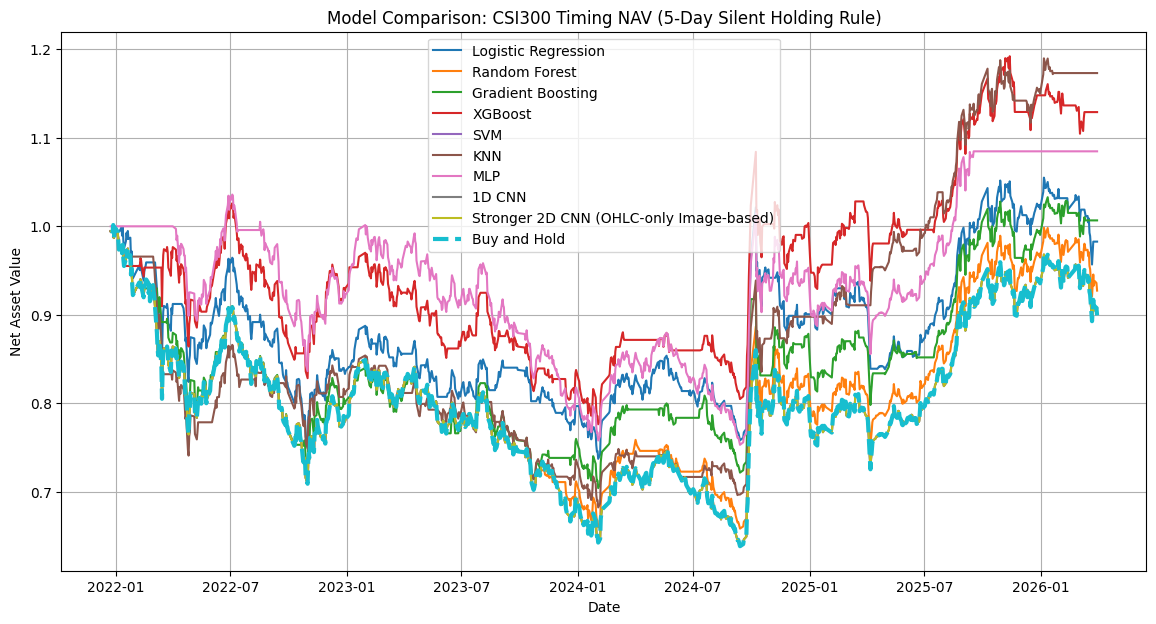

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for model_name, curve_df in model_curves.items():
    plt.plot(curve_df["date"], curve_df["strategy_nav"], label=model_name)

# Use the buy-and-hold curve from the logistic backtest as the common benchmark.
plt.plot(bt_logit["date"], bt_logit["buy_hold_nav"], label="Buy and Hold", linewidth=3, linestyle="--")

plt.title("Model Comparison: CSI300 Timing NAV (5-Day Silent Holding Rule)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.legend()
plt.grid(True)
plt.show()